<a href="https://colab.research.google.com/github/ovirce/360004---AI---SA2-Part-A---Code/blob/main/360004_AI_SA2_Part_A_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#import the dataset
data = pd.read_csv('tested.csv')
#Exploratory Data Analysis
print("First 5 Rows", data.head())
print("Dataset Information", data.info())
print("Statistical Summary", data.describe())

First 5 Rows    PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
D

In [ ]:
#locate missing values
print("Missing values:")
display(data.isnull().sum())#

Missing values:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
#fill the missing values (Dan said to mabe make a predictive algorithm here for the high grade)
data['Age'].fillna(data['Age'].median(), inplace=True) #fill in the age missing values with the mean of age
data['Cabin'].fillna(data['Cabin'].mode()[0], inplace=True) #fill in the cabin missing values with the mode of cabin
data['Fare'].fillna(data['Fare'].mean(), inplace=True) #fill in the fare missing values with the mean of fare

data = data.drop(['PassengerId', 'Name', 'Cabin'], axis=1)

/tmp/ipykernel_481/3360100106.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True) #fill in the age missing values with the mean of age
/tmp/ipykernel_481/3360100106.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [ ]:
data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0
Embarked,0
FamilySize,0
IsAlone,0


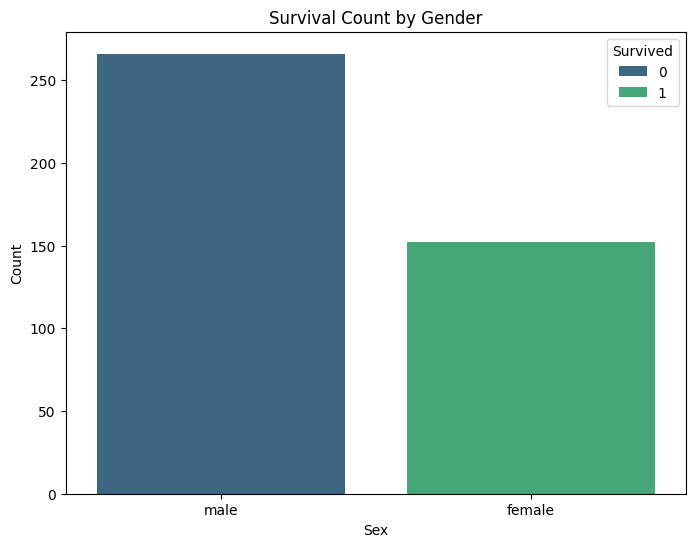

In [ ]:
#categorical
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Sex', hue='Survived', palette='viridis')
plt.title('Survival Count by Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

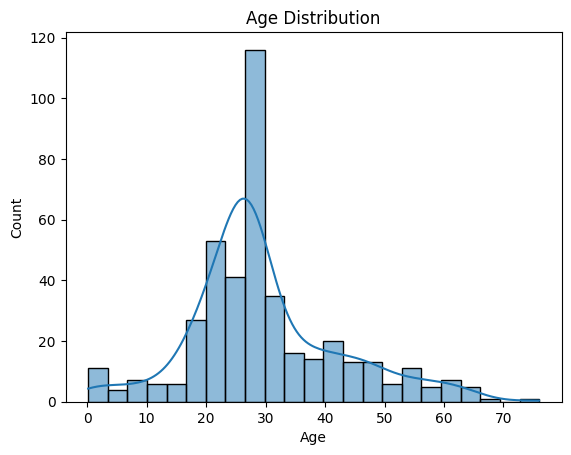

In [ ]:
plt.figure()
sns.histplot(data['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

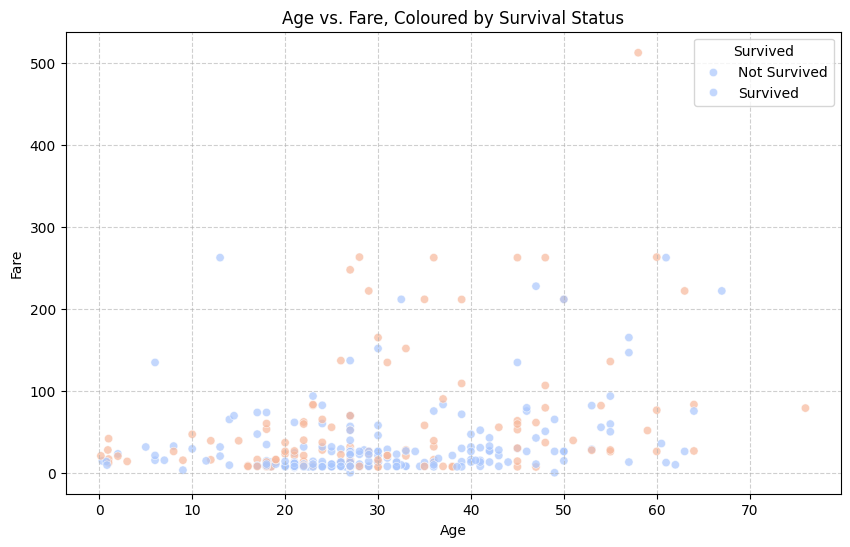

In [ ]:
#relational
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Age', y='Fare', hue='Survived', palette='coolwarm', alpha=0.7)
plt.title('Age vs. Fare, Coloured by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived', loc='upper right', labels=['Not Survived', 'Survived'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

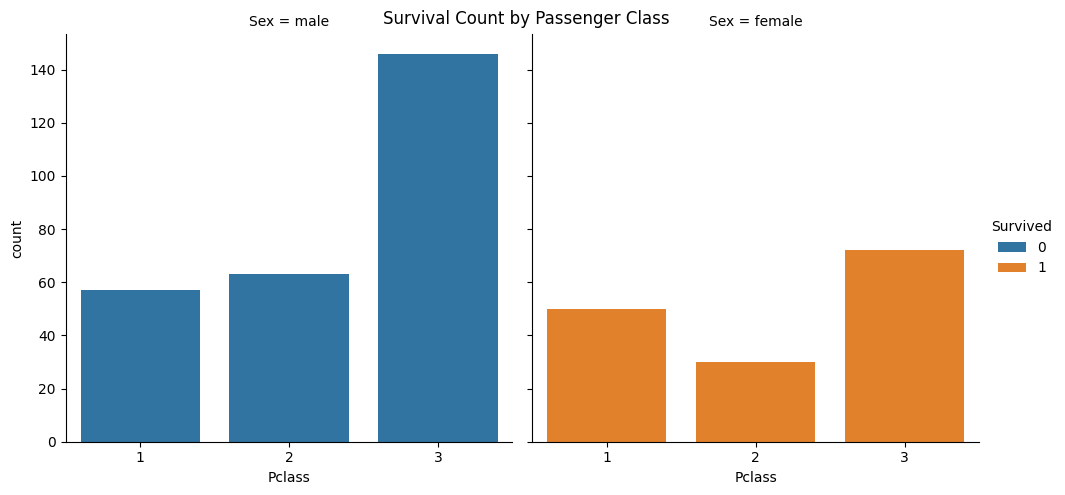

In [ ]:
#hierarchical graph
sns.catplot(x='Pclass', hue='Survived', data = data, kind = 'count', col='Sex')
plt.suptitle('Survival Count by Passenger Class')
plt.show()


In [ ]:
#convert categorical variables into numerical format
data = pd.get_dummies(data, drop_first=True)

In [ ]:
#prepare data
X = data.drop('Survived', axis=1)
y = data['Survived']

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestClassifier(n_estimators=100, max_depth= 5, min_samples_split=10, min_samples_leaf=4, random_state=42)
model.fit(X_train, y_train)
#train model
predictions = model.predict(X_test)

Final Accuracy: 1.0000
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Confusion Matrix
[[50  0]
 [ 0 34]]
Training accuracy: 1.0000
Testing accuracy: 1.0000


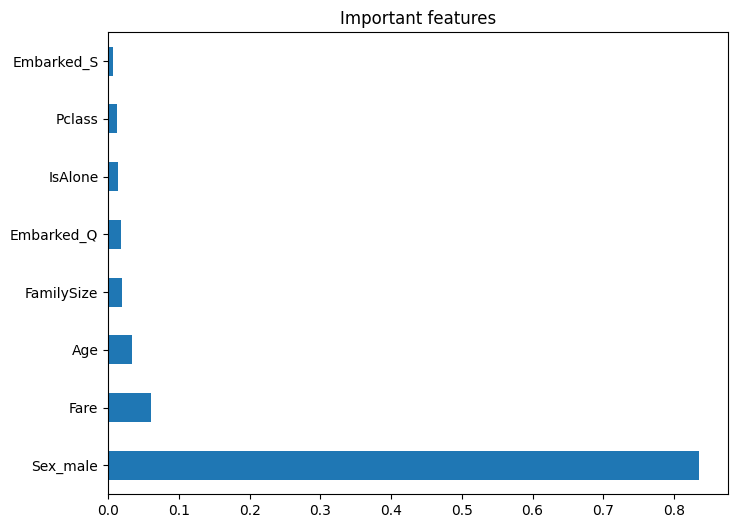

In [ ]:
#evaluation
accuracy = accuracy_score(y_test, predictions)
print(f"Final Accuracy: {accuracy:.4f}")

print("Classification Report")
print(classification_report(y_test, predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, predictions))

print(f"Training accuracy: {model.score(X_train, y_train):.4f}")
print(f"Testing accuracy: {model.score(X_test, y_test):.4f}")

#feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,6))
plt.title("Important features")
plt.show()